In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from functools import partial

# Проверка простой гипотезы

1. Реализовать критерии Крамера-фон Мизеса и Андерсона-Дарлинга, определяя p-value с помощью метода Монте-Карло. Построить график ЭФР p-value при верной гипотезе и проверить, что критерий работает верно. Учтите, что anderson из scipy.stats – это другое!

In [2]:
#Cramer von Mises 

def cvm_stat(data, f0):
  data.sort()
  #get statistics
  n = len(data)
  r_data = [f0(i) for i in data]
  stat = sum([((2*(i+1)-1)/(2*n)-r_data[i])**2 for i in range(n)]) +1/(12*n)
  return stat

def monte_carlo_cvm(N = 10000, n = 1000):
  T = []
  for i in range(N):
    x_data = stats.norm.rvs(size = n)
    T.append(cvm_stat(x_data, f0 = stats.norm.cdf))
  return sorted(T)

def cvm_pval(x_data, f0, T, a =0.05):
  N = len(T)
  stat = cvm_stat(x_data, f0)
  k = 0
  for i in range(N):
    if T[i] < stat:
      k+=1
    else:
      break
  pval = 1 - k/N
  return pval


In [9]:
#НЕ ЗАПУСКАТЬ
T_cvm = monte_carlo_cvm()

KeyboardInterrupt: 

In [ ]:
#НЕ ЗАПУСКАТЬ
with open('cvm_mc.txt', 'w') as f:
    f.write('\n'.join(map(str, T_cvm)))

NameError: name 'T_cvm' is not defined

In [3]:
with open('cvm_mc.txt', 'r') as f:
    T_cvm_file = [float(line.strip()) for line in f if line.strip()]

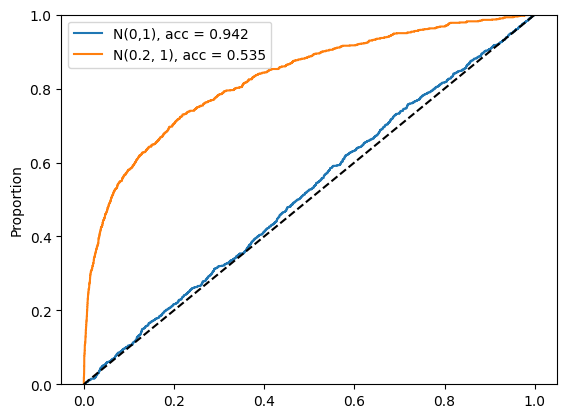

In [4]:
#test cvm for hypothesis and alternative

#hypothesis
k = 1000
n = 100
a = 0.05

p_val = []
acceptance = 0
for i in range(k):
  x_data = stats.norm.rvs(size = n)
  pval = cvm_pval(x_data, stats.norm.cdf, T_cvm_file, a)
  p_val.append(pval)
  if pval >= a:
    acceptance += 1/k
sns.ecdfplot(p_val, label=f'N(0,1), acc = {acceptance:.3f}')

#alternative
mu = 0.2
sigma2 = 1
acceptance = 0
p_val = []
for i in range(k):
  x_data = stats.norm.rvs(mu, sigma2, size = n)
  pval = cvm_pval(x_data, stats.norm.cdf, T_cvm_file, a)
  p_val.append(pval)
  if pval >= a:
    acceptance += 1/k
sns.ecdfplot(p_val, label = f'N({mu}, {sigma2}), acc = {acceptance:.3f}')


x = np.linspace(0,1,1000)
plt.plot(x,x, linestyle = '--', color = 'black')
plt.legend()
plt.show()

In [6]:
#Anderson Darling

def ad_stat(data, f0):
  data.sort()
  n = len(data)
  r_data = [f0(i) for i in data]
  stat = -n-sum([((2*(i+1)-1)/n)*(np.log(r_data[i])+np.log(1-r_data[n-1-i])) for i in range(n)])
  return stat

def monte_carlo_ad(N = 10000, n = 1000):
  T = []
  for i in range(N):
    x_data = stats.norm.rvs(size = n)
    T.append(ad_stat(x_data, f0 = stats.norm.cdf))
  return sorted(T)

def ad_pval(x_data, f0, T, a =0.05):
  N = len(T)
  stat = ad_stat(x_data, f0)
  k = 0
  for i in range(N):
    if T[i] < stat:
      k+=1
    else:
      break
  pval = 1 - k/N
  return pval


In [ ]:
#НЕ ЗАПУСКАТЬ
T_ad = monte_carlo_ad()

In [ ]:
#НЕ ЗАПУСКАТЬ
with open('ad_mc.txt', 'w') as f:
    f.write('\n'.join(map(str, T_ad)))

In [7]:
with open('ad_mc.txt', 'r') as f:
    T_ad_file = [float(line.strip()) for line in f if line.strip()]

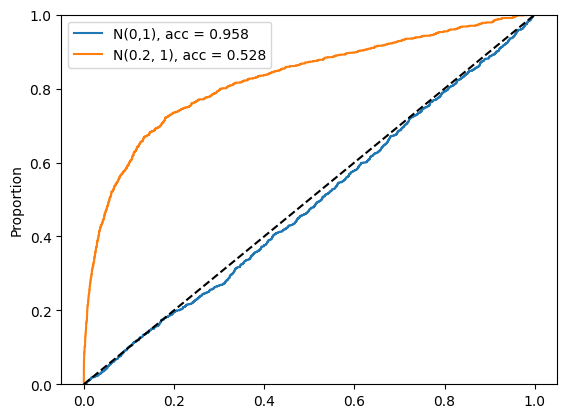

In [8]:
#test cvm for hypothesis and alternative

#hypothesis
k = 1000
n = 100
a = 0.05

p_val = []
acceptance = 0
for i in range(k):
  x_data = stats.norm.rvs(size = n)
  pval = ad_pval(x_data, stats.norm.cdf, T_ad_file, a)
  p_val.append(pval)
  if pval >= a:
    acceptance += 1/k
sns.ecdfplot(p_val, label=f'N(0,1), acc = {acceptance:.3f}')

#alternative
acceptance = 0
mu = 0.2
sigma2 = 1
p_val = []
for i in range(k):
  x_data = stats.norm.rvs(mu, sigma2, size = n)
  pval = ad_pval(x_data, stats.norm.cdf, T_ad_file, a)
  p_val.append(pval)
  if pval >= a:
    acceptance += 1/k
sns.ecdfplot(p_val, label = f'N({mu}, {sigma2}), acc = {acceptance:.3f}')


x = np.linspace(0,1,1000)
plt.plot(x,x, linestyle = '--', color = 'black')
plt.legend()
plt.show()

2. Построить графики p-value критериев Колмогорова, хи-квадрат, Крамера-фон Мизеса, Андерсона-
Дарлинга для проверки гипотезы H0 : Xi ∼ N (0, 1) для а) Xi ∼ pN (0, 1) + (1 − p)N (0, 3) (под суммой имеется ввиду смесь) б) Xi ∼ 0.5N (μ, 1) + 0.5N (−μ, 1), p = 0.9, μ = 0.1. Подобрать n так, чтобы все критерии были чувствительны к гипотезе (то есть график p-value существенно отличался от биссектрисы, но не становился вертикальным). Какой критерий лучше справляется с задачей? Как вы это определили?

In [8]:
p = 0.9
mu = 0.1
k = 1000

def generate_a(n, p = 0.9):
  data = []
  for i in range(n):
    y = np.random.uniform()
    if y < p:
      data.append(stats.norm.rvs())
    else:
      data.append(stats.norm.rvs(0, np.sqrt(3)))
  return np.array(data)


def generate_b(n, p = 0.1):
  data = []
  for i in range(n):
    y = np.random.uniform()
    if y < 0.5:
      data.append(stats.norm.rvs(p, 1))
    else:
      data.append(stats.norm.rvs((-1)*p, 1))
  return np.array(data)


def chi_norm(x_data):
  n = len(x_data)
  k = int(np.log2(n))
  quantiles = [-np.inf]
  for i in range(1,k):
    quantiles.append(stats.norm.ppf(q = i/k))
  quantiles.append(np.inf)
  counts, bin_edges = np.histogram(x_data, bins=quantiles)
  p_val = stats.chisquare(counts, [n/k]*k)[1]
  return p_val



#a
def criterions(generate, k = 100,output = True, a =0.05):
  ks_p_val = []
  chi_p_val = []
  cvm_p_val = []
  ad_p_val = []

  acc_ks = 0
  acc_chi = 0
  acc_cvm = 0
  acc_ad = 0

  for _ in range(k):
    x_data = generate()

    ks_p = stats.kstest(x_data, stats.norm.cdf)[1]
    cvm_p = cvm_pval(x_data, stats.norm.cdf, T_cvm_file)
    ad_p = ad_pval(x_data, stats.norm.cdf, T_ad_file)
    chi_p = chi_norm(x_data)

    if ks_p >= a:
      acc_ks += 1/k
    if cvm_p >= a:
      acc_cvm += 1/k
    if ad_p >= a:
      acc_ad += 1/k
    if chi_p >= a:
      acc_chi += 1/k

    ks_p_val.append(ks_p)
    ad_p_val.append(ad_p)
    cvm_p_val.append(cvm_p)
    chi_p_val.append(chi_p)

  if output:
    sns.ecdfplot(ks_p_val, label = f'KS, acc = {acc_ks:.3f}', color = 'navy')
    sns.ecdfplot(ad_p_val, label = f'AD, acc = {acc_ad:.3f}', color = 'red')
    sns.ecdfplot(cvm_p_val, label = f'CVM, acc = {acc_cvm:.3f}', color = 'forestgreen')
    sns.ecdfplot(chi_p_val, label = f'CHI2, acc = {acc_chi:.3f}', color = 'hotpink')

    x = np.linspace(0,1, 1000)
    plt.plot(x,x, color ='black', linestyle = '--')
    plt.legend()
    plt.show()

  return ks_p_val, ad_p_val, cvm_p_val, chi_p_val




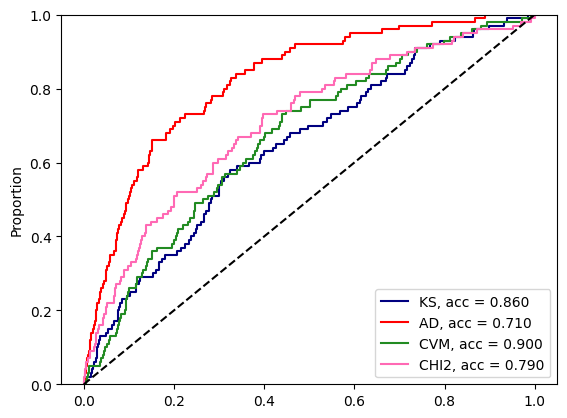

In [10]:
ks, ad, cvm, chi = criterions(partial(generate_a, n = 1000))

In [11]:
def criterions_chi_only(generate, k = 100,output = True, a =0.05):
  #ks_p_val = []
  chi_p_val = []
  #cvm_p_val = []
  #ad_p_val = []

  acc_ks = 0
  acc_chi = 0
  acc_cvm = 0
  acc_ad = 0

  for _ in range(k):
    x_data = generate()

    #ks_p = stats.kstest(x_data, stats.norm.cdf)[1]
    #cvm_p = cvm_pval(x_data, stats.norm.cdf, T_cvm_file)
    #ad_p = ad_pval(x_data, stats.norm.cdf, T_ad_file)
    chi_p = chi_norm(x_data)
    """
    if ks_p >= a:
      acc_ks += 1/k
    if cvm_p >= a:
      acc_cvm += 1/k
    if ad_p >= a:
      acc_ad += 1/k
    """
    if chi_p >= a:
      acc_chi += 1/k

    #ks_p_val.append(ks_p)
    #ad_p_val.append(ad_p)
    #cvm_p_val.append(cvm_p)
    chi_p_val.append(chi_p)

  if output:
    #sns.ecdfplot(ks_p_val, label = f'KS, acc = {acc_ks:.3f}', color = 'navy')
    #sns.ecdfplot(ad_p_val, label = f'AD, acc = {acc_ad:.3f}', color = 'red')
    #sns.ecdfplot(cvm_p_val, label = f'CVM, acc = {acc_cvm:.3f}', color = 'forestgreen')
    sns.ecdfplot(chi_p_val, label = f'CHI2, acc = {acc_chi:.3f}', color = 'hotpink')

    x = np.linspace(0,1, 1000)
    plt.plot(x,x, color ='black', linestyle = '--')
    plt.legend()
    plt.show()

  return chi_p_val




In [12]:
#НЕ ЗАПУСКАТЬ
chi = criterions_chi_only(partial(generate_b, n = 100000), output=False)

In [ ]:
#НЕ ЗАПУСКАТЬ
with open('ad_p_val.txt', 'w') as f:
    f.write('\n'.join(map(str, ad)))

In [ ]:
#НЕ ЗАПУСКАТЬ
with open('ks_p_val.txt', 'w') as f:
    f.write('\n'.join(map(str, ks)))

In [ ]:
#НЕ ЗАПУСКАТЬ
with open('cvm_p_val.txt', 'w') as f:
    f.write('\n'.join(map(str, cvm)))

In [13]:
#НЕ ЗАПУСКАТЬ
with open('chi_p_val.txt', 'w') as f:
    f.write('\n'.join(map(str, chi)))

In [14]:
with open('ad_p_val.txt', 'r') as f:
    ad_p_file = [float(line.strip()) for line in f if line.strip()]
with open('cvm_p_val.txt', 'r') as f:
    cvm_p_file = [float(line.strip()) for line in f if line.strip()]
with open('ks_p_val.txt', 'r') as f:
    ks_p_file = [float(line.strip()) for line in f if line.strip()]
with open('chi_p_val.txt', 'r') as f:
    chi_p_file = [float(line.strip()) for line in f if line.strip()]


C:\Users\NEKDAR\AppData\Local\Temp\ipykernel_1204\2515375371.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


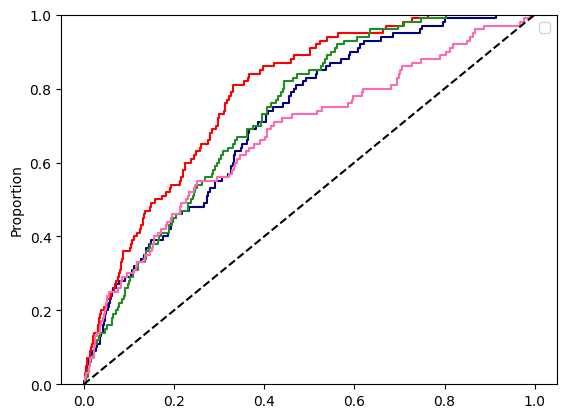

In [16]:
sns.ecdfplot(ks_p_file, color = 'navy')
sns.ecdfplot(ad_p_file, color = 'red')
sns.ecdfplot(cvm_p_file, color = 'forestgreen')
sns.ecdfplot(chi_p_file, color = 'hotpink')

x = np.linspace(0,1, 1000)
plt.plot(x,x, color ='black', linestyle = '--')
plt.legend()
plt.show()

3.  Для предыдущей задачи построить график мощности всех четырех критериев уровня 95% как функции от параметра p или μ соответственно.

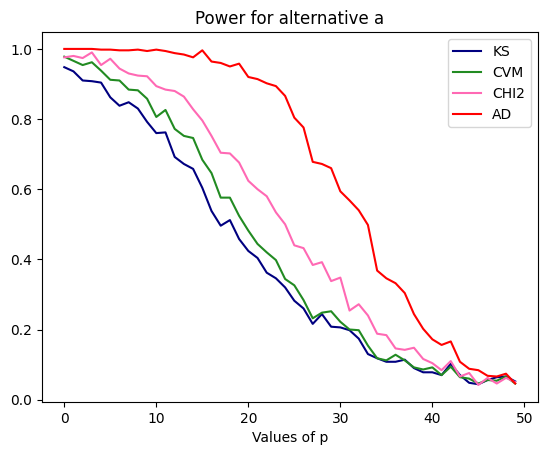

In [17]:
runs = 50
a = 0.05

ks_b = []
cvm_b = []
ad_b = []
chi_b = []

for i in range(runs):
  ks, ad, cvm, chi = criterions(partial(generate_a, n = 100, p = i/runs), k = 500, output = False)
  ks_ecdf = stats.ecdf(ks)
  ad_ecdf = stats.ecdf(ad)
  cvm_ecdf = stats.ecdf(cvm)
  chi_ecdf = stats.ecdf(chi)

  ks_b.append(ks_ecdf.cdf.evaluate(a))
  ad_b.append(ad_ecdf.cdf.evaluate(a))
  cvm_b.append(cvm_ecdf.cdf.evaluate(a))
  chi_b.append(chi_ecdf.cdf.evaluate(a))

x = np.linspace(0,1,100)
plt.plot(ks_b, label=f'KS', color = 'navy')
plt.plot(cvm_b, label=f'CVM', color = 'forestgreen')
plt.plot(chi_b, label = f'CHI2', color = 'hotpink')
plt.plot(ad_b, label = f'AD', color = 'red')
plt.legend()
plt.xlabel('Values of p')
plt.title('Power for alternative a')
plt.show()



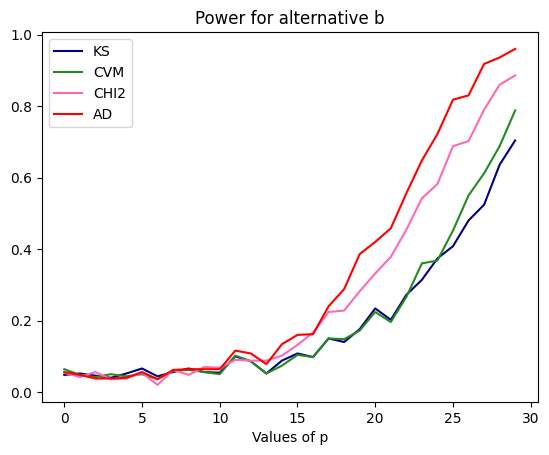

In [18]:
runs = 30
a = 0.05

ks_b = []
cvm_b = []
ad_b = []
chi_b = []

for i in range(runs):
  ks, ad, cvm, chi = criterions(partial(generate_b, n = 100, p = i/runs), k = 500, output= False)
  ks_ecdf = stats.ecdf(ks)
  ad_ecdf = stats.ecdf(ad)
  cvm_ecdf = stats.ecdf(cvm)
  chi_ecdf = stats.ecdf(chi)

  ks_b.append(ks_ecdf.cdf.evaluate(a))
  ad_b.append(ad_ecdf.cdf.evaluate(a))
  cvm_b.append(cvm_ecdf.cdf.evaluate(a))
  chi_b.append(chi_ecdf.cdf.evaluate(a))

x = np.linspace(0,1,100)
plt.plot(ks_b, label=f'KS', color = 'navy')
plt.plot(cvm_b, label=f'CVM', color = 'forestgreen')
plt.plot(chi_b, label = f'CHI2', color = 'hotpink')
plt.plot(ad_b, label = f'AD', color = 'red')
plt.legend()
plt.xlabel('Values of p')
plt.title('Power for alternative b')
plt.show()

